# Diamond Price Prediction: Regression Study

## Aim and Review 1 checklist

The aim is to predict a diamond's price from its physical measurements and quality grades. I use one reproducible 80/20 split for every model so that the final comparison is fair. The notebook covers the full regression portion of the Review 1 rubric: data audit and EDA, cleaning, a justified engineered feature, leakage-safe preprocessing, all ten required regressors, tuning, a shared test-set comparison, five-fold cross-validation for the two leading models, and diagnostics for the final choice.

Prices are in US dollars. `random_state=42` is used wherever randomness is involved so that another team member can reproduce the same results.

### Import the required libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

### Load the assigned dataset

The two candidate paths make the notebook portable: the first works when Jupyter starts in the project root, and the second works when it starts inside `models/`.

In [2]:
data_candidates = [Path("data/diamond.csv"), Path("../data/diamond.csv")]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/diamond.csv from the current directory.")

diamonds = pd.read_csv(data_path)
print(f"Loaded: {data_path.resolve()}")
print(f"Original shape: {diamonds.shape[0]:,} rows × {diamonds.shape[1]} columns")
diamonds.head()

Loaded: /home/chifuyu/College/3rd Year/5th SEM/ML/ml-capstone/data/diamond.csv
Original shape: 53,940 rows × 10 columns


,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Rename columns for easier use

In [3]:
diamonds = diamonds.rename(
    columns={
        "Carat(Weight of Daimond)": "carat",
        "Cut(Quality)": "cut",
        "Color": "color",
        "Clarity": "clarity",
        "Depth": "depth",
        "Table": "table",
        "Price(in US dollars)": "price",
        "X(length)": "x",
        "Y(width)": "y",
        "Z(Depth)": "z",
    }
)
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Initial data audit

Before changing anything, I check the shape, data types, missing values, exact duplicate rows, descriptive statistics, and the target range. This provides a record of what was actually found rather than assuming that the dataset is already clean.

In [4]:
diamonds.info()

quality_report = pd.DataFrame(
    {
        "Data type": diamonds.dtypes.astype(str),
        "Missing values": diamonds.isna().sum(),
        "Unique values": diamonds.nunique(),
    }
)
print(f"Exact duplicate rows: {diamonds.duplicated().sum():,}")
print(
    f"Target range: ${diamonds['price'].min():,} to ${diamonds['price'].max():,}; "
    f"median = ${diamonds['price'].median():,.0f}"
)
quality_report

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
Exact duplicate rows: 146
Target range: $326 to $18,823; median = $2,401


,Data type,Missing values,Unique values
carat,float64,0,273
cut,str,0,5
color,str,0,7
clarity,str,0,8
depth,float64,0,184
table,float64,0,127
price,int64,0,11602
x,float64,0,554
y,float64,0,552
z,float64,0,375


In [5]:
diamonds.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carat,53940.0,NaN,NaN,NaN,0.79794,0.474011,0.2,0.4,0.7,1.04,5.01
cut,53940,5,Ideal,21551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,53940,7,G,11292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clarity,53940,8,SI1,13065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
depth,53940.0,NaN,NaN,NaN,61.749405,1.432621,43.0,61.0,61.8,62.5,79.0
table,53940.0,NaN,NaN,NaN,57.457184,2.234491,43.0,56.0,57.0,59.0,95.0
price,53940.0,NaN,NaN,NaN,3932.799722,3989.439738,326.0,950.0,2401.0,5324.25,18823.0
x,53940.0,NaN,NaN,NaN,5.731157,1.121761,0.0,4.71,5.7,6.54,10.74
y,53940.0,NaN,NaN,NaN,5.734526,1.142135,0.0,4.72,5.71,6.54,58.9
z,53940.0,NaN,NaN,NaN,3.538734,0.705699,0.0,2.91,3.53,4.04,31.8


### Cleaning and outlier audit

There are two different issues here. Exact duplicates add no new information, so I remove them. A zero or negative physical dimension is impossible, so those rows are also removed. High-carat and high-price diamonds can be genuine rather than mistakes; instead of deleting them, I report IQR outlier counts and later cap **predictor** extremes at the 1st and 99th percentiles learned from each training fold. This keeps rare diamonds while limiting their leverage, and the test set never determines the clipping limits.

In [6]:
dimension_columns = ["x", "y", "z"]
duplicate_count = int(diamonds.duplicated().sum())
diamonds_clean = diamonds.drop_duplicates().copy()
invalid_dimensions = (diamonds_clean[dimension_columns] <= 0).any(axis=1)
invalid_dimension_count = int(invalid_dimensions.sum())
diamonds_clean = diamonds_clean.loc[~invalid_dimensions].copy()

numeric_columns_before_engineering = diamonds_clean.select_dtypes(include="number").columns
outlier_rows = []
for column in numeric_columns_before_engineering:
    q1, q3 = diamonds_clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    count = int(
        ((diamonds_clean[column] < q1 - 1.5 * iqr)
         | (diamonds_clean[column] > q3 + 1.5 * iqr)).sum()
    )
    outlier_rows.append(
        {"Column": column, "IQR outliers": count, "Percent of rows": 100 * count / len(diamonds_clean)}
    )

print(f"Removed exact duplicates: {duplicate_count:,}")
print(f"Removed rows with impossible dimensions: {invalid_dimension_count:,}")
print(f"Cleaned shape: {diamonds_clean.shape[0]:,} rows × {diamonds_clean.shape[1]} columns")
pd.DataFrame(outlier_rows).round(2)

Removed exact duplicates: 146
Removed rows with impossible dimensions: 19
Cleaned shape: 53,775 rows × 10 columns


,Column,IQR outliers,Percent of rows
0,carat,1867,3.47
1,depth,2523,4.69
2,table,603,1.12
3,price,3520,6.55
4,x,24,0.04
5,y,22,0.04
6,z,29,0.05


## Exploratory data analysis

The plots below cover every predictor, the target distribution, correlations, and two feature–target relationships. To keep the plots readable, a fixed sample is used only for scatter-plot rendering; the models still use the complete cleaned dataset.

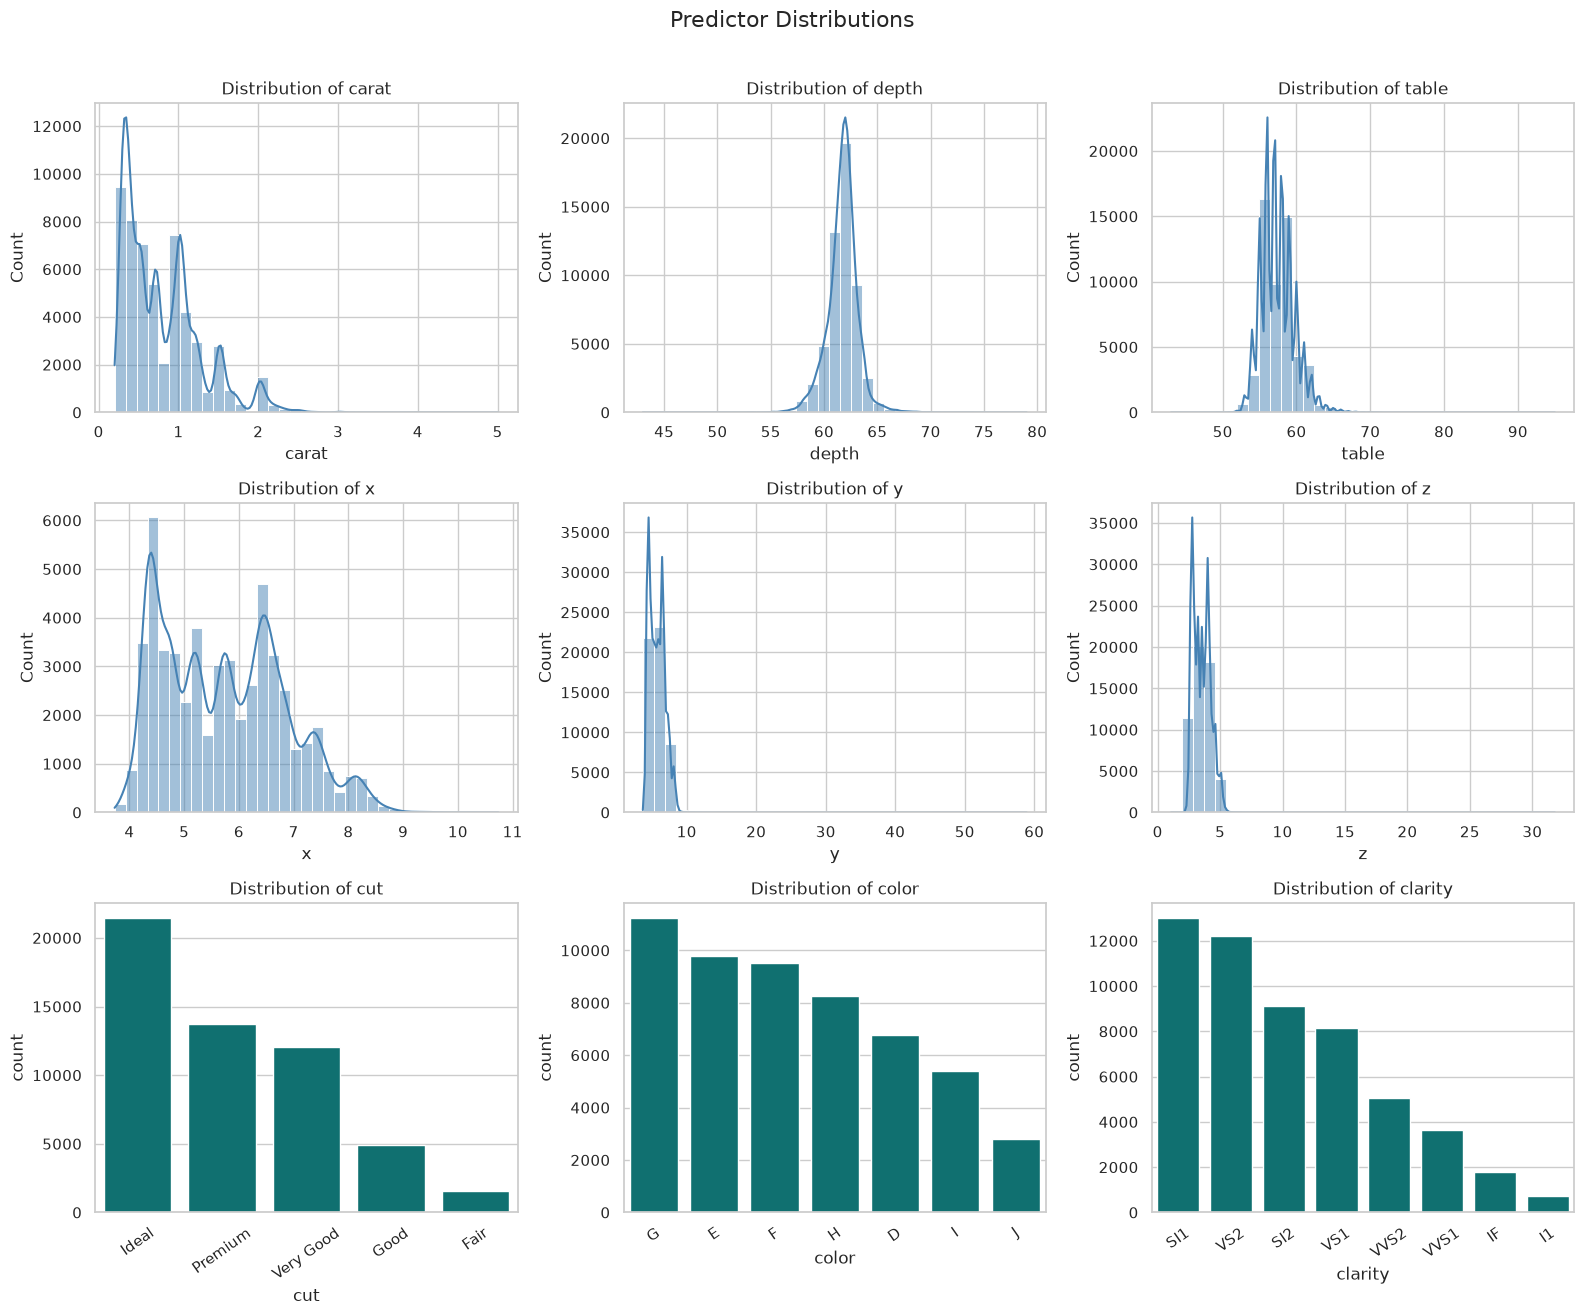

In [7]:
numeric_eda_features = ["carat", "depth", "table", "x", "y", "z"]
categorical_eda_features = ["cut", "color", "clarity"]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for axis, column in zip(axes.flat[:6], numeric_eda_features):
    sns.histplot(diamonds_clean[column], bins=35, kde=True, ax=axis, color="steelblue")
    axis.set_title(f"Distribution of {column}")
for axis, column in zip(axes.flat[6:], categorical_eda_features):
    order = diamonds_clean[column].value_counts().index
    sns.countplot(data=diamonds_clean, x=column, order=order, ax=axis, color="teal")
    axis.tick_params(axis="x", rotation=35)
    axis.set_title(f"Distribution of {column}")
plt.suptitle("Predictor Distributions", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

**What stands out:** carat and the three dimensions are right-skewed because small diamonds are much more common than large ones. Depth is tightly concentrated near 62%, whereas table has a wider spread. The quality variables are also imbalanced: `Ideal` is the most common cut, colour `G` occurs most often, and `SI1`/`VS2` are the largest clarity groups. This is useful context when interpreting one-hot coefficients later.

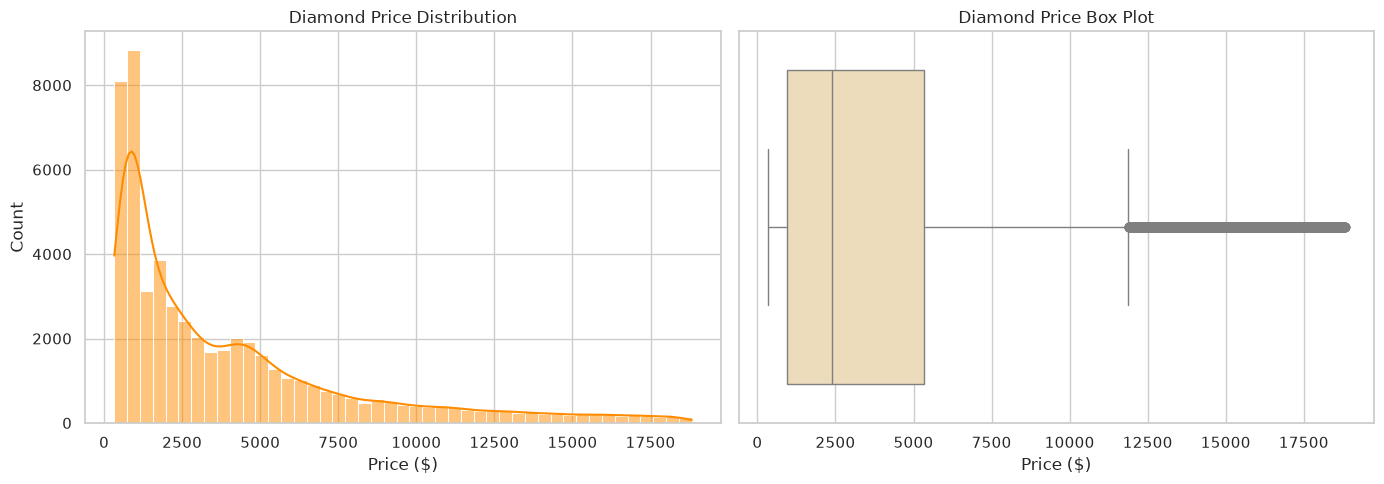

,price
count,53775.00
mean,3931.22
std,3985.92
min,326.00
25%,951.00
50%,2401.00
75%,5324.00
90%,9813.60
99%,17365.26
max,18823.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(diamonds_clean["price"], bins=45, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Diamond Price Distribution")
axes[0].set_xlabel("Price ($)")
sns.boxplot(x=diamonds_clean["price"], ax=axes[1], color="wheat")
axes[1].set_title("Diamond Price Box Plot")
axes[1].set_xlabel("Price ($)")
plt.tight_layout()
plt.show()

diamonds_clean["price"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("price").round(2)

**Target observation:** price has a long right tail: the median is much lower than the upper end of the range. RMSE will therefore react strongly to mistakes on expensive diamonds, while MAE gives a more typical dollar error. Reporting both avoids presenting an overly favourable single metric.

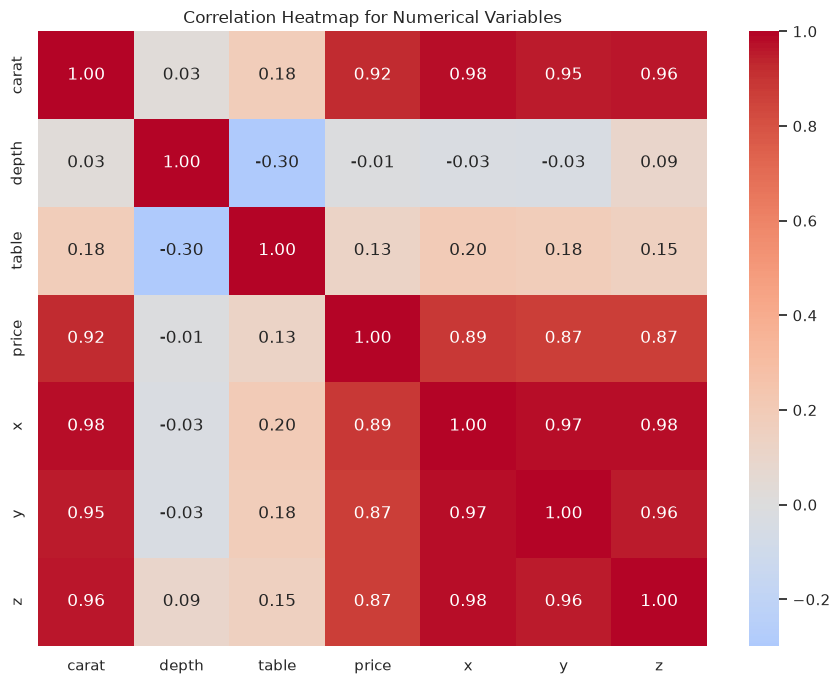

In [9]:
correlation_matrix = diamonds_clean.select_dtypes(include="number").corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Numerical Variables")
plt.tight_layout()
plt.show()

**Correlation observation:** carat has the strongest linear relationship with price (about 0.92). Length, width, and physical depth are also strongly related to both carat and price, so multicollinearity is expected; this is one reason Ridge, Lasso, and ElasticNet are useful comparisons. The percentage-depth variable has almost no linear correlation with price.

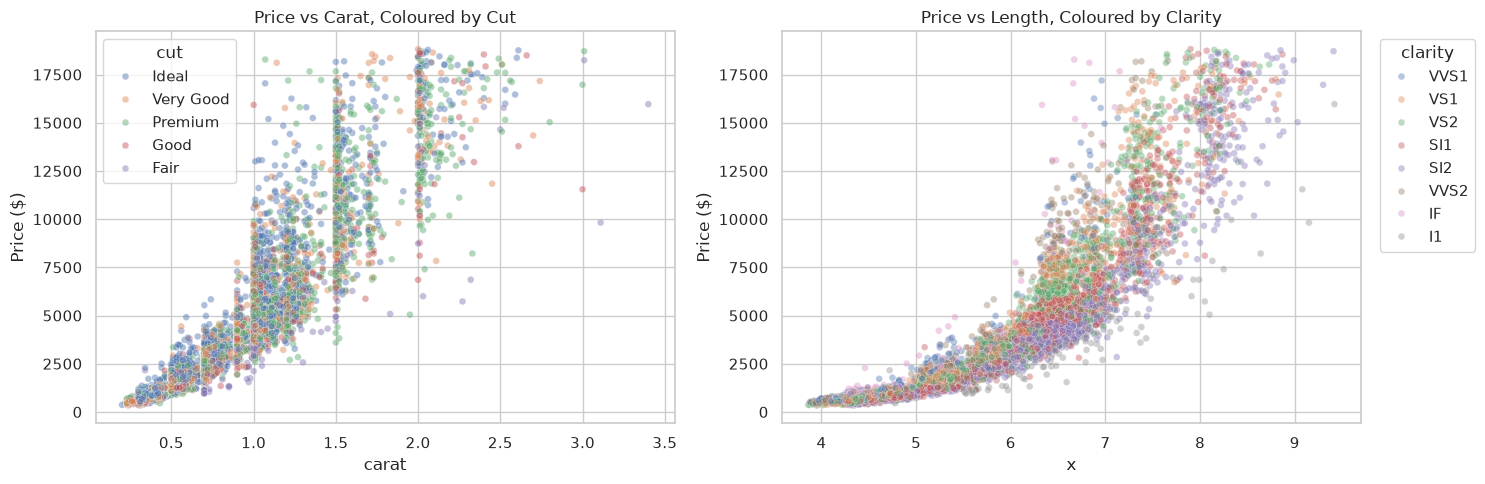

In [10]:
plot_sample = diamonds_clean.sample(n=min(8_000, len(diamonds_clean)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=plot_sample, x="carat", y="price", hue="cut", alpha=0.45, s=24, ax=axes[0])
axes[0].set_title("Price vs Carat, Coloured by Cut")
axes[0].set_ylabel("Price ($)")
sns.scatterplot(data=plot_sample, x="x", y="price", hue="clarity", alpha=0.4, s=24, ax=axes[1])
axes[1].set_title("Price vs Length, Coloured by Clarity")
axes[1].set_ylabel("Price ($)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="clarity")
plt.tight_layout()
plt.show()

**Relationship observation:** price rises nonlinearly with both carat and length, and the vertical spread becomes larger for bigger stones. Diamonds with similar sizes can still have very different prices because cut, colour, and clarity matter too. The curved pattern suggests that purely linear models may leave structure in their residuals, so polynomial, tree, ensemble, kernel, and neighbour models are worth testing.

## Feature engineering

I add `volume_proxy = x × y × z`. It is not intended as an exact geological volume; it is a compact interaction between the three measurements. Price depends strongly on stone size, and this feature lets simpler models use their combined effect directly. It is computed from input columns only, so it does not leak the target.

In [11]:
diamonds_clean["volume_proxy"] = (
    diamonds_clean["x"] * diamonds_clean["y"] * diamonds_clean["z"]
)
print(f"Correlation between volume proxy and price: {diamonds_clean['volume_proxy'].corr(diamonds_clean['price']):.3f}")
diamonds_clean[["x", "y", "z", "volume_proxy", "price"]].head()

Correlation between volume proxy and price: 0.904


,x,y,z,volume_proxy,price
0,3.95,3.98,2.43,38.202030,326
1,3.89,3.84,2.31,34.505856,326
2,4.05,4.07,2.31,38.076885,327
3,4.20,4.23,2.63,46.724580,334
4,4.34,4.35,2.75,51.917250,335


### Separate features and target

`price` is the continuous target. The remaining nine columns are input features.

In [12]:
X = diamonds_clean.drop(columns="price")
y = diamonds_clean["price"]

numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target: price")

Numerical features: ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume_proxy']
Categorical features: ['cut', 'color', 'clarity']
Target: price


### Create the training and test sets

The same 80/20 split and random state should be retained for all ten models to make their scores directly comparable.

In [13]:
# Stratification is applied to deciles because the target itself is continuous.
# This keeps cheap and expensive diamonds represented similarly in both sets.
price_strata = pd.qcut(y, q=10, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_strata,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Overall median price: ${y.median():,.0f}")
print(f"Train/test median prices: ${y_train.median():,.0f} / ${y_test.median():,.0f}")

Training rows: 43,020
Test rows: 10,755
Overall median price: $2,401
Train/test median prices: $2,401 / $2,400


### Leakage-safe preprocessing

Numerical columns are median-imputed, clipped using percentiles learned only from the current training fold, and standardized. Categorical columns are mode-imputed and one-hot encoded. Keeping every operation inside each model pipeline prevents information from validation or test rows leaking into training.

In [14]:
class PercentileClipper(BaseEstimator, TransformerMixin):
    # Cap each numeric predictor using limits learned during fit.

    def __init__(self, lower=1.0, upper=99.0):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanpercentile(values, self.lower, axis=0)
        self.upper_bounds_ = np.nanpercentile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        return np.clip(
            np.asarray(X, dtype=float), self.lower_bounds_, self.upper_bounds_
        )

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("outlier_cap", PercentileClipper(lower=1.0, upper=99.0)),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

### Train Model 1: Multiple Linear Regression

In [15]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_regression_model.fit(X_train, y_train)
print("Linear Regression training complete.")

Linear Regression training complete.


### Evaluate the model

- **R²:** Proportion of variation in diamond prices explained by the model; closer to 1 is better.
- **RMSE:** Typical prediction error in dollars, with larger errors penalized more heavily.
- **MAE:** Average absolute prediction error in dollars.

In [16]:
train_predictions = linear_regression_model.predict(X_train)
test_predictions = linear_regression_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "R2 Score": r2_score(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
    }

train_metrics = regression_metrics(y_train, train_predictions)
test_metrics = regression_metrics(y_test, test_predictions)

pd.DataFrame([train_metrics, test_metrics], index=["Training set", "Test set"]).round(3)

,R2 Score,RMSE,MAE
Training set,0.930,1052.502,695.157
Test set,0.929,1061.555,706.729


In [17]:
results_df = pd.DataFrame(
    [
        {
            "Model": "Multiple Linear Regression",
            **test_metrics,
        }
    ]
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Multiple Linear Regression,0.929,1061.555,706.729


### Visualize predictions and residuals

A good model places points near the diagonal in the actual-versus-predicted plot. Residuals should be scattered around zero without a strong pattern.

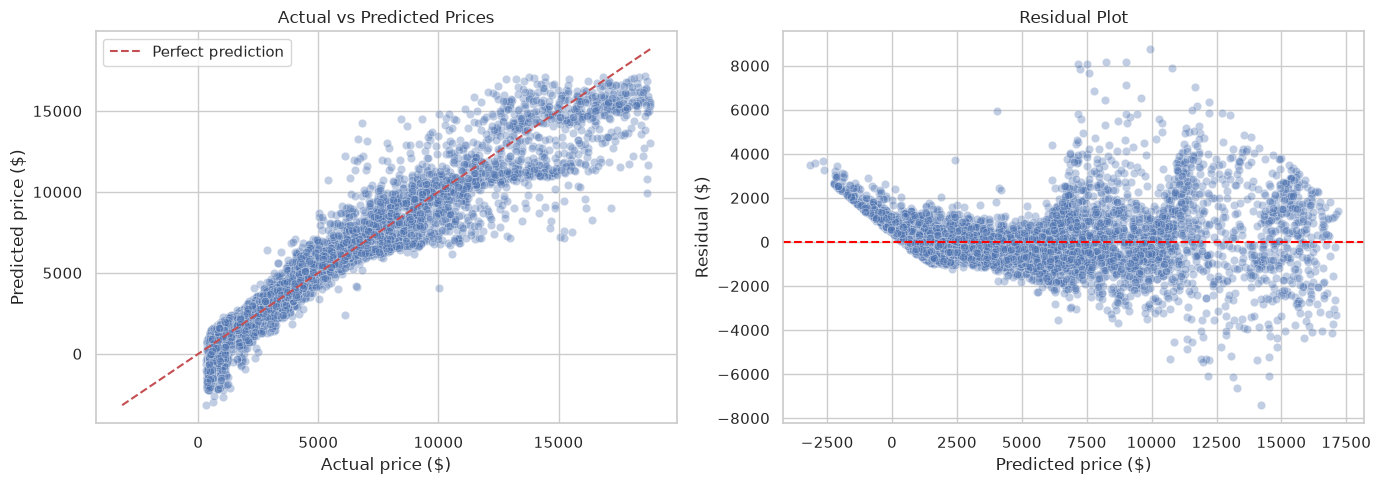

In [18]:
residuals = y_test - test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=test_predictions, alpha=0.35, ax=axes[0])
plot_min = min(y_test.min(), test_predictions.min())
plot_max = max(y_test.max(), test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--", label="Perfect prediction")
axes[0].set(title="Actual vs Predicted Prices", xlabel="Actual price ($)", ylabel="Predicted price ($)")
axes[0].legend()

sns.scatterplot(x=test_predictions, y=residuals, alpha=0.35, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(title="Residual Plot", xlabel="Predicted price ($)", ylabel="Residual ($)")

plt.tight_layout()
plt.show()

### Inspect the most influential coefficients

Because numerical inputs were standardized, their coefficients represent the change associated with one standard deviation. One-hot coefficients are relative to the category dropped by the encoder. Coefficients show association, not causation.

In [19]:
fitted_preprocessor = linear_regression_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = linear_regression_model.named_steps["regressor"].coef_

coefficient_table = pd.DataFrame(
    {"Feature": feature_names, "Coefficient": coefficients}
)
coefficient_table["Absolute Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table.sort_values("Absolute Coefficient", ascending=False).head(15)

,Feature,Coefficient,Absolute Coefficient
17,categorical__clarity_IF,4851.062114,4851.062114
22,categorical__clarity_VVS1,4518.472283,4518.472283
23,categorical__clarity_VVS2,4459.262920,4459.262920
20,categorical__clarity_VS1,4117.059871,4117.059871
21,categorical__clarity_VS2,3804.463879,3804.463879
0,numerical__carat,3353.463255,3353.463255
18,categorical__clarity_SI1,3221.900346,3221.900346
6,numerical__volume_proxy,3033.062268,3033.062268
16,categorical__color_J,-2411.042469,2411.042469
19,categorical__clarity_SI2,2262.443059,2262.443059


## Model 1 conclusion

Multiple Linear Regression provides the baseline scores for this project. Its assumptions can limit performance when the relationships between diamond attributes and price are nonlinear. The next model should be compared using the same cleaned data, split, preprocessing approach, and metrics.

## Model 2: Ridge Regression

Ridge Regression adds an L2 penalty to Linear Regression. It shrinks large coefficients and can make the model more stable when features are correlated. The regularization strength is controlled by `alpha`: a larger value applies stronger shrinkage.

### Tune and train Ridge Regression

Three-fold cross-validation tests several `alpha` values using only the training set. The value with the lowest cross-validation RMSE is selected automatically.

In [20]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge()),
    ]
)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"regressor__alpha": np.logspace(-3, 3, 7)},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
ridge_search.fit(X_train, y_train)
ridge_model = ridge_search.best_estimator_

print(f"Best Ridge alpha: {ridge_search.best_params_['regressor__alpha']:.4g}")
print(f"Best cross-validation RMSE: {-ridge_search.best_score_:,.3f}")

Best Ridge alpha: 1
Best cross-validation RMSE: 1,054.867


### Evaluate Ridge Regression

Both training and test metrics are shown to help identify underfitting or overfitting. The test metrics are then added to the shared comparison table.

In [21]:
ridge_train_predictions = ridge_model.predict(X_train)
ridge_test_predictions = ridge_model.predict(X_test)

ridge_train_metrics = regression_metrics(y_train, ridge_train_predictions)
ridge_test_metrics = regression_metrics(y_test, ridge_test_predictions)

pd.DataFrame(
    [ridge_train_metrics, ridge_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.930,1052.517,694.748
Test set,0.929,1061.539,706.293


In [22]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Ridge Regression", **ridge_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Ridge Regression,0.929,1061.539,706.293
1,Multiple Linear Regression,0.929,1061.555,706.729


### Model 2 conclusion

Compare Ridge with the baseline. If its test error is lower, coefficient shrinkage improved generalization. A similar score is also reasonable because both models still assume linear relationships.

## Model 3: Lasso Regression

Lasso Regression adds an L1 penalty. In addition to shrinking coefficients, it can reduce some coefficients exactly to zero, effectively selecting a smaller set of useful features.

### Tune and train Lasso Regression

As with Ridge, three-fold cross-validation chooses `alpha` from the training data. `max_iter` is increased to give the optimization algorithm enough iterations to converge.

In [23]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Lasso(max_iter=20_000)),
    ]
)

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={"regressor__alpha": np.logspace(-2, 3, 7)},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
lasso_search.fit(X_train, y_train)
lasso_model = lasso_search.best_estimator_

print(f"Best Lasso alpha: {lasso_search.best_params_['regressor__alpha']:.4g}")
print(f"Best cross-validation RMSE: {-lasso_search.best_score_:,.3f}")

Best Lasso alpha: 0.01
Best cross-validation RMSE: 1,054.924


### Evaluate Lasso Regression

In [24]:
lasso_train_predictions = lasso_model.predict(X_train)
lasso_test_predictions = lasso_model.predict(X_test)

lasso_train_metrics = regression_metrics(y_train, lasso_train_predictions)
lasso_test_metrics = regression_metrics(y_test, lasso_test_predictions)

pd.DataFrame(
    [lasso_train_metrics, lasso_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.930,1052.502,695.098
Test set,0.929,1061.551,706.667


In [25]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Lasso Regression", **lasso_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Ridge Regression,0.929,1061.539,706.293
1,Lasso Regression,0.929,1061.551,706.667
2,Multiple Linear Regression,0.929,1061.555,706.729


### Inspect Lasso feature selection

The table lists the coefficients retained by Lasso. Features assigned a coefficient of zero were excluded by regularization.

In [26]:
lasso_feature_names = lasso_model.named_steps["preprocessor"].get_feature_names_out()
lasso_coefficients = lasso_model.named_steps["regressor"].coef_
lasso_coefficient_table = pd.DataFrame(
    {"Feature": lasso_feature_names, "Coefficient": lasso_coefficients}
)
selected_features = lasso_coefficient_table.loc[
    lasso_coefficient_table["Coefficient"] != 0
].copy()
selected_features["Absolute Coefficient"] = selected_features["Coefficient"].abs()

print(f"Features available after preprocessing: {len(lasso_coefficients)}")
print(f"Features retained by Lasso: {len(selected_features)}")
selected_features.sort_values("Absolute Coefficient", ascending=False)

Features available after preprocessing: 24
Features retained by Lasso: 24


,Feature,Coefficient,Absolute Coefficient
17,categorical__clarity_IF,4845.752965,4845.752965
22,categorical__clarity_VVS1,4513.321100,4513.321100
23,categorical__clarity_VVS2,4454.187191,4454.187191
20,categorical__clarity_VS1,4112.018369,4112.018369
21,categorical__clarity_VS2,3799.472474,3799.472474
0,numerical__carat,3351.343216,3351.343216
18,categorical__clarity_SI1,3216.952643,3216.952643
6,numerical__volume_proxy,3034.666527,3034.666527
16,categorical__color_J,-2410.218249,2410.218249
19,categorical__clarity_SI2,2257.498218,2257.498218


## Comparison of Models 1–3

The best model should have the highest test R² and the lowest test RMSE and MAE. Since all three models use the same data split, their results are directly comparable.

,Model,R2 Score,RMSE,MAE
0,Ridge Regression,0.929,1061.539,706.293
1,Lasso Regression,0.929,1061.551,706.667
2,Multiple Linear Regression,0.929,1061.555,706.729


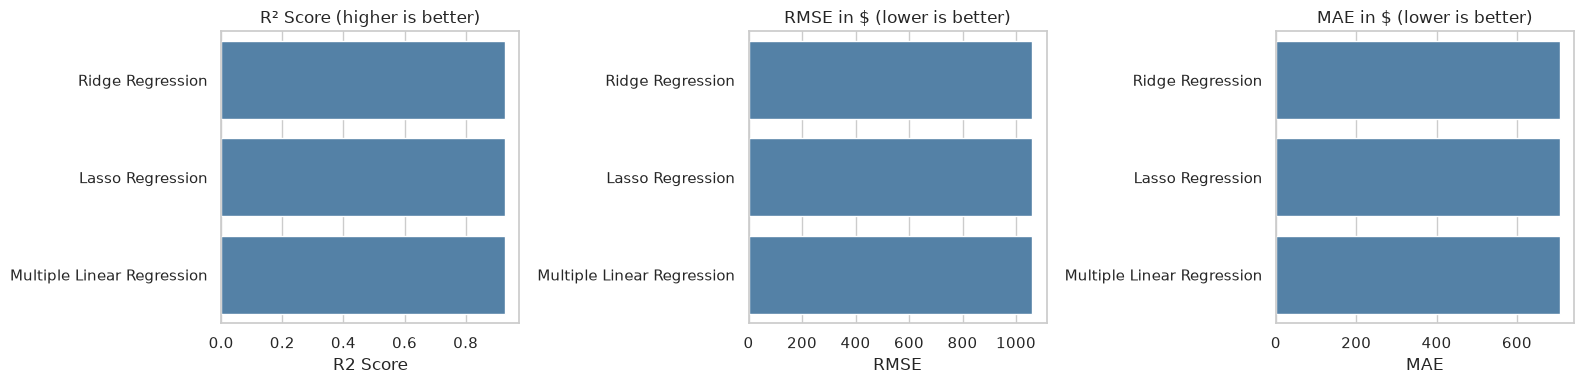

In [27]:
display(results_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metric_config = [
    ("R2 Score", "R² Score (higher is better)"),
    ("RMSE", "RMSE in $ (lower is better)"),
    ("MAE", "MAE in $ (lower is better)"),
]

for axis, (metric, title) in zip(axes, metric_config):
    sns.barplot(data=results_df, x=metric, y="Model", ax=axis, color="steelblue")
    axis.set_title(title)
    axis.set_ylabel("")

plt.tight_layout()
plt.show()

### Model 3 conclusion

Lasso is useful when a simpler linear model is desired because it can discard weak encoded features. However, like Linear and Ridge Regression, it cannot directly learn nonlinear price relationships. A nonlinear algorithm is therefore a useful next comparison.

## Model 4: ElasticNet Regression

ElasticNet combines L1 regularization from Lasso with L2 regularization from Ridge. This allows it to shrink coefficients, remove weak features, and remain more stable when predictors are correlated.

### Tune `alpha` and `l1_ratio`

`alpha` controls the overall regularization strength. `l1_ratio` controls the mixture: values near 1 behave more like Lasso, while values near 0 behave more like Ridge. Three-fold cross-validation chooses the combination with the lowest validation RMSE using only the training set.

In [28]:
elastic_net_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            ElasticNet(max_iter=20_000, random_state=RANDOM_STATE),
        ),
    ]
)

elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid={
        "regressor__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
        "regressor__l1_ratio": [0.1, 0.5, 0.9],
    },
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
elastic_net_search.fit(X_train, y_train)
elastic_net_model = elastic_net_search.best_estimator_

print("Best ElasticNet parameters:", elastic_net_search.best_params_)
print(f"Best cross-validation RMSE: {-elastic_net_search.best_score_:,.3f}")

Best ElasticNet parameters: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.9}
Best cross-validation RMSE: 1,054.952


### Evaluate ElasticNet

In [29]:
elastic_train_predictions = elastic_net_model.predict(X_train)
elastic_test_predictions = elastic_net_model.predict(X_test)

elastic_train_metrics = regression_metrics(y_train, elastic_train_predictions)
elastic_test_metrics = regression_metrics(y_test, elastic_test_predictions)

pd.DataFrame(
    [elastic_train_metrics, elastic_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.930,1052.771,693.560
Test set,0.929,1061.711,705.028


In [30]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "ElasticNet Regression", **elastic_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Ridge Regression,0.929,1061.539,706.293
1,Lasso Regression,0.929,1061.551,706.667
2,Multiple Linear Regression,0.929,1061.555,706.729
3,ElasticNet Regression,0.929,1061.711,705.028


### Inspect coefficient sparsity

The L1 component can set coefficients exactly to zero. This cell reports how many transformed features ElasticNet retained and displays the strongest coefficients.

In [31]:
elastic_feature_names = elastic_net_model.named_steps["preprocessor"].get_feature_names_out()
elastic_coefficients = elastic_net_model.named_steps["regressor"].coef_
elastic_coefficient_table = pd.DataFrame(
    {"Feature": elastic_feature_names, "Coefficient": elastic_coefficients}
)
elastic_coefficient_table["Absolute Coefficient"] = (
    elastic_coefficient_table["Coefficient"].abs()
)
elastic_selected_features = elastic_coefficient_table.loc[
    elastic_coefficient_table["Coefficient"] != 0
]

print(f"Features available after preprocessing: {len(elastic_coefficients)}")
print(f"Features retained by ElasticNet: {len(elastic_selected_features)}")
elastic_selected_features.sort_values(
    "Absolute Coefficient", ascending=False
).head(15)

Features available after preprocessing: 24
Features retained by ElasticNet: 24


,Feature,Coefficient,Absolute Coefficient
17,categorical__clarity_IF,4633.365089,4633.365089
22,categorical__clarity_VVS1,4308.873290,4308.873290
23,categorical__clarity_VVS2,4252.464098,4252.464098
20,categorical__clarity_VS1,3912.723293,3912.723293
21,categorical__clarity_VS2,3601.941414,3601.941414
0,numerical__carat,3313.933206,3313.933206
6,numerical__volume_proxy,3057.899536,3057.899536
18,categorical__clarity_SI1,3020.841378,3020.841378
16,categorical__color_J,-2397.417692,2397.417692
19,categorical__clarity_SI2,2063.735978,2063.735978


### Model 4 conclusion

ElasticNet provides a compromise between Ridge's stability and Lasso's feature selection. Compare its chosen `l1_ratio`, coefficient sparsity, and test metrics with Models 2 and 3 to see whether mixing both penalties helped.

## Model 5: Polynomial Regression

Polynomial Regression applies `PolynomialFeatures` before Linear Regression. This creates squared terms and pairwise interactions, allowing a linear estimator to represent curved and interacting relationships.

### Compare polynomial degrees

Degrees 1 and 2 are compared on a validation split created from the training data. Degree 1 reproduces an ordinary linear relationship; degree 2 adds squared and interaction terms. Degree 3 is intentionally excluded because one-hot expansion followed by cubic expansion would create thousands of dense features and excessive memory use.

In [32]:
X_poly_train, X_poly_validation, y_poly_train, y_poly_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

polynomial_candidates = {}
polynomial_degree_rows = []

for degree in [1, 2]:
    candidate_model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("polynomial_features", PolynomialFeatures(degree=degree, include_bias=False)),
            ("regressor", LinearRegression()),
        ]
    )
    candidate_model.fit(X_poly_train, y_poly_train)
    validation_predictions = candidate_model.predict(X_poly_validation)
    validation_metrics = regression_metrics(y_poly_validation, validation_predictions)
    polynomial_candidates[degree] = candidate_model
    polynomial_degree_rows.append(
        {"Degree": degree, **validation_metrics}
    )

polynomial_degree_results = pd.DataFrame(polynomial_degree_rows).sort_values(
    "RMSE", ignore_index=True
)
best_polynomial_degree = int(polynomial_degree_results.loc[0, "Degree"])
print(f"Selected polynomial degree: {best_polynomial_degree}")
display(polynomial_degree_results.round(3))

Selected polynomial degree: 2


,Degree,R2 Score,RMSE,MAE
0,2,0.968,715.013,396.784
1,1,0.931,1045.227,690.961


### Refit Polynomial Regression on the full training set

In [33]:
polynomial_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "polynomial_features",
            PolynomialFeatures(degree=best_polynomial_degree, include_bias=False),
        ),
        ("regressor", LinearRegression()),
    ]
)
polynomial_model.fit(X_train, y_train)
generated_feature_count = polynomial_model.named_steps[
    "polynomial_features"
].n_output_features_
print(f"Generated polynomial features: {generated_feature_count:,}")

Generated polynomial features: 324


### Evaluate Polynomial Regression

In [34]:
polynomial_train_predictions = polynomial_model.predict(X_train)
polynomial_test_predictions = polynomial_model.predict(X_test)

polynomial_train_metrics = regression_metrics(y_train, polynomial_train_predictions)
polynomial_test_metrics = regression_metrics(y_test, polynomial_test_predictions)

pd.DataFrame(
    [polynomial_train_metrics, polynomial_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.974,644.124,388.731
Test set,0.970,685.682,399.863


In [35]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [{"Model": "Polynomial Regression", **polynomial_test_metrics}]
        ),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Polynomial Regression,0.970,685.682,399.863
1,Ridge Regression,0.929,1061.539,706.293
2,Lasso Regression,0.929,1061.551,706.667
3,Multiple Linear Regression,0.929,1061.555,706.729
4,ElasticNet Regression,0.929,1061.711,705.028


### Plot Polynomial Regression predictions and residuals

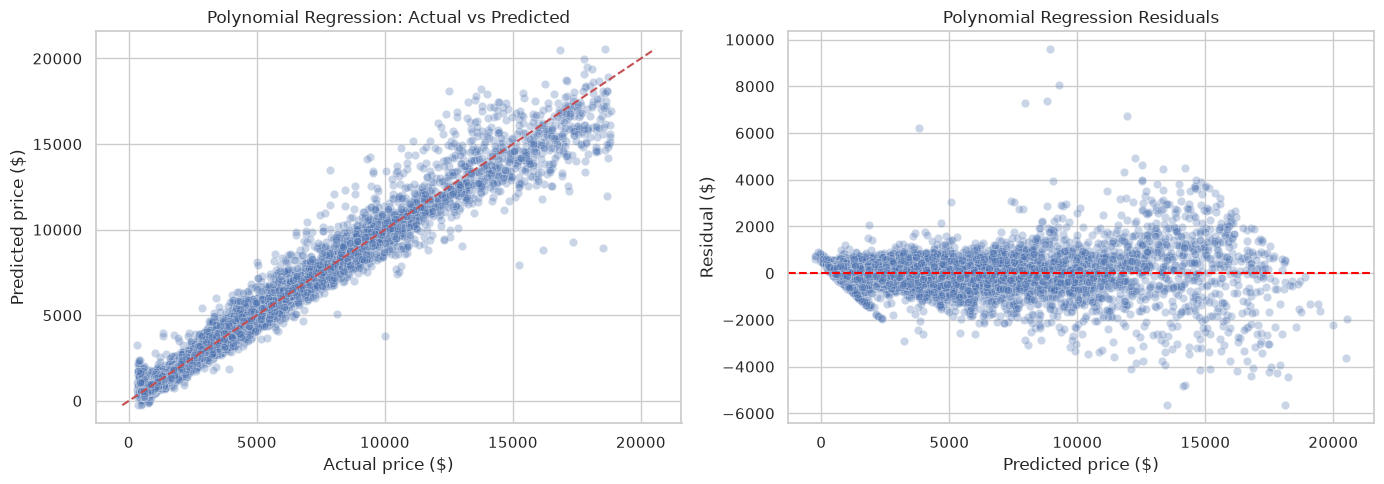

In [36]:
polynomial_residuals = y_test - polynomial_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=polynomial_test_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), polynomial_test_predictions.min())
plot_max = max(y_test.max(), polynomial_test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set(
    title="Polynomial Regression: Actual vs Predicted",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
sns.scatterplot(
    x=polynomial_test_predictions, y=polynomial_residuals, alpha=0.3, ax=axes[1]
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="Polynomial Regression Residuals",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

### Model 5 conclusion

Polynomial Regression tests whether squared terms and feature interactions improve on the linear baseline. The validation comparison determines whether the added flexibility of degree 2 is justified, while the training–test gap indicates whether it overfits.

## Model 6: Decision Tree Regressor

A Decision Tree repeatedly splits the feature space into regions and predicts a price from the training diamonds in each final region. Unlike the first three models, it can learn nonlinear relationships and interactions without requiring polynomial features.

### Tune and train the Decision Tree

An unrestricted tree can memorize its training data. Three-fold cross-validation therefore selects the tree depth and minimum leaf size that give the lowest validation RMSE. `clone(preprocessor)` creates an independent preprocessing copy for this model.

In [37]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("regressor", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

decision_tree_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid={
        "regressor__max_depth": [8, 12, 16, None],
        "regressor__min_samples_leaf": [1, 2, 5],
    },
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
decision_tree_search.fit(X_train, y_train)
decision_tree_model = decision_tree_search.best_estimator_

print("Best Decision Tree parameters:", decision_tree_search.best_params_)
print(f"Best cross-validation RMSE: {-decision_tree_search.best_score_:,.3f}")

Best Decision Tree parameters: {'regressor__max_depth': 16, 'regressor__min_samples_leaf': 5}
Best cross-validation RMSE: 821.747


### Evaluate the Decision Tree

A much better training score than test score indicates overfitting. The selected depth and number of leaves help explain the fitted tree's complexity.

In [38]:
tree_train_predictions = decision_tree_model.predict(X_train)
tree_test_predictions = decision_tree_model.predict(X_test)

tree_train_metrics = regression_metrics(y_train, tree_train_predictions)
tree_test_metrics = regression_metrics(y_test, tree_test_predictions)
fitted_tree = decision_tree_model.named_steps["regressor"]

print(f"Fitted tree depth: {fitted_tree.get_depth()}")
print(f"Number of leaf nodes: {fitted_tree.get_n_leaves():,}")
pd.DataFrame(
    [tree_train_metrics, tree_test_metrics],
    index=["Training set", "Test set"],
).round(3)

Fitted tree depth: 16
Number of leaf nodes: 3,888


,R2 Score,RMSE,MAE
Training set,0.983,513.038,247.260
Test set,0.958,818.197,374.688


In [39]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Decision Tree Regression", **tree_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Polynomial Regression,0.970,685.682,399.863
1,Decision Tree Regression,0.958,818.197,374.688
2,Ridge Regression,0.929,1061.539,706.293
3,Lasso Regression,0.929,1061.551,706.667
4,Multiple Linear Regression,0.929,1061.555,706.729
5,ElasticNet Regression,0.929,1061.711,705.028


### Inspect Decision Tree feature importance

The required feature-importance analysis shows which transformed inputs produced the largest total reductions in squared error across the fitted tree. Correlated features can divide importance between themselves, so these values should be interpreted as model diagnostics rather than causal effects.

In [40]:
tree_feature_names = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()
tree_importance = pd.DataFrame(
    {
        "Feature": tree_feature_names,
        "Importance": fitted_tree.feature_importances_,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

tree_importance.head(15)

,Feature,Importance
0,numerical__volume_proxy,0.639418
1,numerical__y,0.255378
2,categorical__clarity_SI2,0.019301
3,categorical__clarity_SI1,0.013753
4,categorical__color_J,0.012053
5,categorical__color_I,0.009067
6,categorical__color_H,0.007579
7,numerical__carat,0.005986
8,categorical__clarity_VS1,0.005145
9,categorical__clarity_VVS2,0.004408


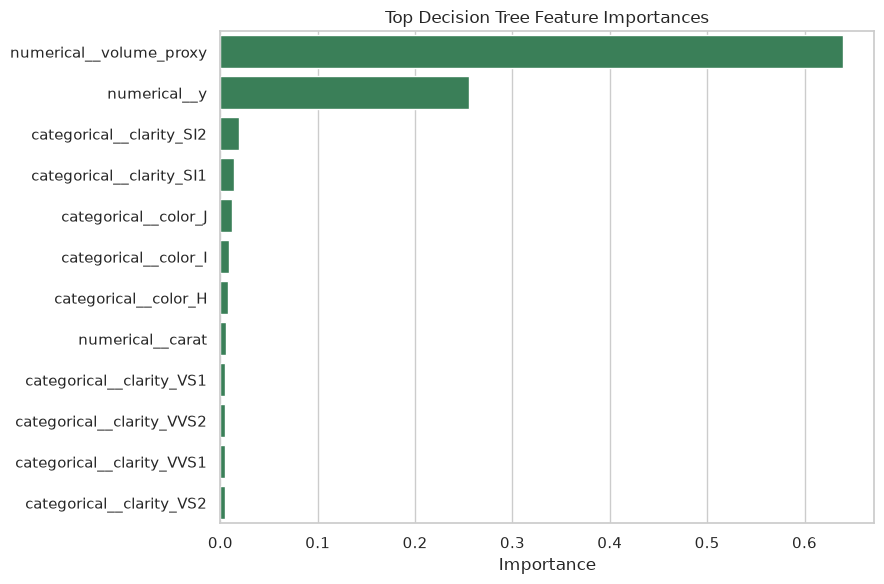

In [41]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=tree_importance.head(12),
    x="Importance",
    y="Feature",
    color="seagreen",
)
plt.title("Top Decision Tree Feature Importances")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 6 conclusion

The Decision Tree can outperform linear models when price depends on nonlinear thresholds and feature interactions. Its training–test score gap should be checked carefully because a single tree is sensitive to the training sample and can overfit.

## Model 7: Random Forest Regressor

A Random Forest trains many decision trees on bootstrapped samples and averages their predictions. Random feature subsets make the trees less correlated, usually improving generalization and stability over one Decision Tree.

### Tune `n_estimators` and train the Random Forest

The required `n_estimators` tuning compares forests containing 100, 200, and 300 trees. `oob_score=True` evaluates each candidate using training rows that were excluded from individual bootstrap samples, so the test set remains untouched during selection. The candidate with the highest out-of-bag R² is retained.

In [42]:
forest_candidates = {}
forest_tuning_rows = []

for number_of_trees in [100, 200, 300]:
    candidate_model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "regressor",
                RandomForestRegressor(
                    n_estimators=number_of_trees,
                    min_samples_leaf=1,
                    max_features=1.0,
                    bootstrap=True,
                    oob_score=True,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    candidate_model.fit(X_train, y_train)
    candidate_oob_r2 = candidate_model.named_steps["regressor"].oob_score_
    forest_candidates[number_of_trees] = candidate_model
    forest_tuning_rows.append(
        {"n_estimators": number_of_trees, "OOB R2 Score": candidate_oob_r2}
    )

forest_tuning_results = pd.DataFrame(forest_tuning_rows).sort_values(
    "OOB R2 Score", ascending=False, ignore_index=True
)
best_n_estimators = int(forest_tuning_results.loc[0, "n_estimators"])
random_forest_model = forest_candidates[best_n_estimators]
fitted_forest = random_forest_model.named_steps["regressor"]

print(f"Selected n_estimators: {best_n_estimators}")
display(forest_tuning_results.round(4))

Selected n_estimators: 300


,n_estimators,OOB R2 Score
0,300,0.9752
1,200,0.9752
2,100,0.9749


### Evaluate the Random Forest

In [43]:
forest_train_predictions = random_forest_model.predict(X_train)
forest_test_predictions = random_forest_model.predict(X_test)

forest_train_metrics = regression_metrics(y_train, forest_train_predictions)
forest_test_metrics = regression_metrics(y_test, forest_test_predictions)

pd.DataFrame(
    [forest_train_metrics, forest_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.997,231.993,107.620
Test set,0.973,651.897,297.054


In [44]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Random Forest Regression", **forest_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Random Forest Regression,0.973,651.897,297.054
1,Polynomial Regression,0.970,685.682,399.863
2,Decision Tree Regression,0.958,818.197,374.688
3,Ridge Regression,0.929,1061.539,706.293
4,Lasso Regression,0.929,1061.551,706.667
5,Multiple Linear Regression,0.929,1061.555,706.729
6,ElasticNet Regression,0.929,1061.711,705.028


### Inspect Random Forest feature importance

Impurity-based importance measures how much each transformed feature contributes to reducing prediction error across the forest. It is useful for interpretation, although correlated features may share importance.

In [45]:
forest_feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
forest_importance = pd.DataFrame(
    {
        "Feature": forest_feature_names,
        "Importance": fitted_forest.feature_importances_,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

forest_importance.head(15)

,Feature,Importance
0,numerical__volume_proxy,0.664455
1,numerical__y,0.207112
2,numerical__carat,0.020697
3,categorical__clarity_SI2,0.019084
4,categorical__clarity_SI1,0.013685
5,categorical__color_J,0.011212
6,categorical__color_I,0.008494
7,categorical__color_H,0.006986
8,categorical__clarity_VS2,0.005286
9,numerical__depth,0.005230


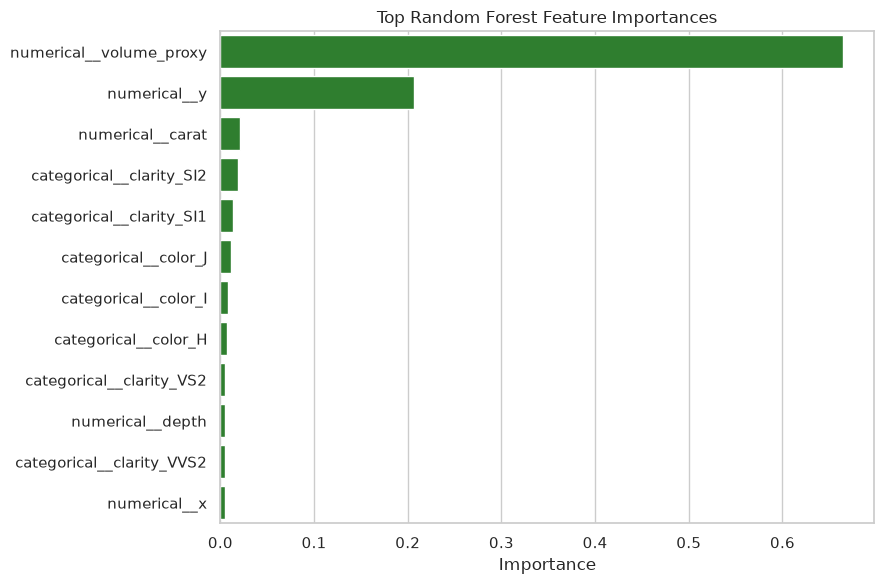

In [46]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=forest_importance.head(12),
    x="Importance",
    y="Feature",
    color="forestgreen",
)
plt.title("Top Random Forest Feature Importances")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Comparison of Models 1–7

All seven models use the same cleaned observations and test set. Rank them primarily by test R² while also checking RMSE, MAE, and the difference between training and test performance.

,Model,R2 Score,RMSE,MAE
0,Random Forest Regression,0.973,651.897,297.054
1,Polynomial Regression,0.970,685.682,399.863
2,Decision Tree Regression,0.958,818.197,374.688
3,Ridge Regression,0.929,1061.539,706.293
4,Lasso Regression,0.929,1061.551,706.667
5,Multiple Linear Regression,0.929,1061.555,706.729
6,ElasticNet Regression,0.929,1061.711,705.028


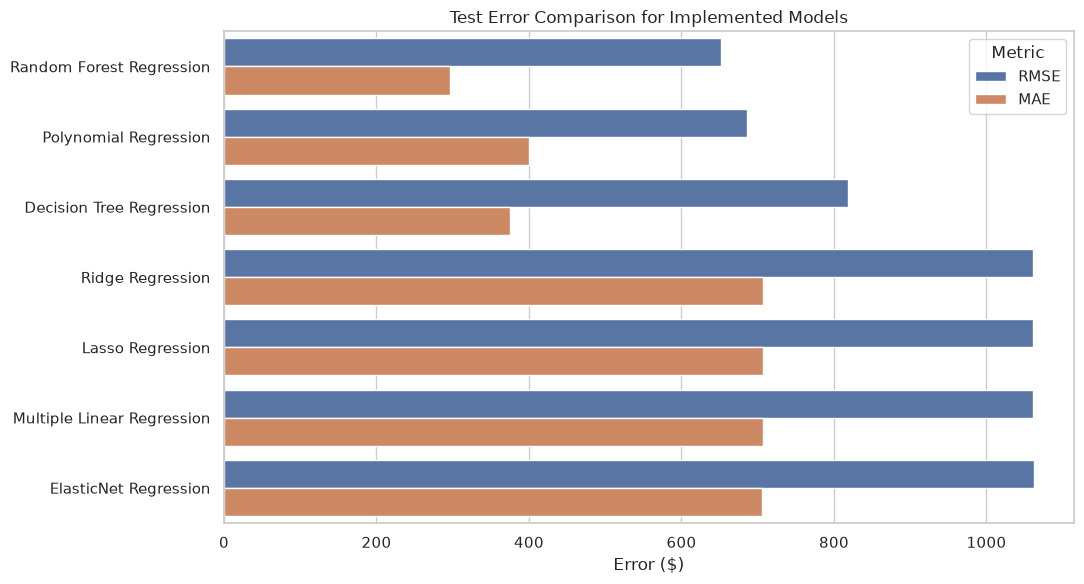

In [47]:
display(results_df.round(3))

comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Error ($)",
)
plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_long, x="Error ($)", y="Model", hue="Metric")
plt.title("Test Error Comparison for Implemented Models")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 7 conclusion

Random Forest usually provides a substantial improvement over a single tree by averaging away some of its variance. Compare its out-of-bag R² with its test R²; similar values suggest that its test performance is a reliable estimate of generalization.

## Model 8: Gradient Boosting Regressor

Gradient Boosting builds shallow decision trees sequentially. Each new tree learns to correct errors made by the existing ensemble, allowing the model to capture complex nonlinear relationships in diamond prices.

### Tune the learning rate

Following the required algorithm notes, `learning_rate` is tuned. Twenty percent of the existing training set is used as a temporary validation set. The test set remains untouched, preventing test-data leakage during model selection.

In [48]:
X_boost_train, X_boost_validation, y_boost_train, y_boost_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

boosting_candidates = {}
boosting_tuning_rows = []

for learning_rate in [0.03, 0.05, 0.10]:
    candidate_model = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "regressor",
                GradientBoostingRegressor(
                    n_estimators=250,
                    learning_rate=learning_rate,
                    max_depth=3,
                    min_samples_leaf=3,
                    subsample=0.8,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    candidate_model.fit(X_boost_train, y_boost_train)
    validation_predictions = candidate_model.predict(X_boost_validation)
    validation_rmse = np.sqrt(
        mean_squared_error(y_boost_validation, validation_predictions)
    )
    boosting_candidates[learning_rate] = candidate_model
    boosting_tuning_rows.append(
        {"learning_rate": learning_rate, "Validation RMSE": validation_rmse}
    )

boosting_tuning_results = pd.DataFrame(boosting_tuning_rows).sort_values(
    "Validation RMSE", ignore_index=True
)
best_learning_rate = float(boosting_tuning_results.loc[0, "learning_rate"])
print(f"Selected learning_rate: {best_learning_rate}")
display(boosting_tuning_results.round(3))

Selected learning_rate: 0.1


,learning_rate,Validation RMSE
0,0.10,752.586
1,0.05,829.634
2,0.03,900.940


### Refit Gradient Boosting on the full training set

After selecting the learning rate, a fresh model is trained using every row in the original training split.

In [49]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            GradientBoostingRegressor(
                n_estimators=250,
                learning_rate=best_learning_rate,
                max_depth=3,
                min_samples_leaf=3,
                subsample=0.8,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
gradient_boosting_model.fit(X_train, y_train)
print("Gradient Boosting training complete.")

Gradient Boosting training complete.


### Evaluate Gradient Boosting

In [50]:
boosting_train_predictions = gradient_boosting_model.predict(X_train)
boosting_test_predictions = gradient_boosting_model.predict(X_test)

boosting_train_metrics = regression_metrics(y_train, boosting_train_predictions)
boosting_test_metrics = regression_metrics(y_test, boosting_test_predictions)

pd.DataFrame(
    [boosting_train_metrics, boosting_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.969,701.532,367.035
Test set,0.964,759.233,389.272


In [51]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [{"Model": "Gradient Boosting Regressor", **boosting_test_metrics}]
        ),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Random Forest Regression,0.973,651.897,297.054
1,Polynomial Regression,0.970,685.682,399.863
2,Gradient Boosting Regressor,0.964,759.233,389.272
3,Decision Tree Regression,0.958,818.197,374.688
4,Ridge Regression,0.929,1061.539,706.293
5,Lasso Regression,0.929,1061.551,706.667
6,Multiple Linear Regression,0.929,1061.555,706.729
7,ElasticNet Regression,0.929,1061.711,705.028


### Inspect learning progress and feature importance

Training deviance shows how the ensemble's loss changes as trees are added. The feature-importance plot identifies the transformed inputs used most strongly by the fitted ensemble.

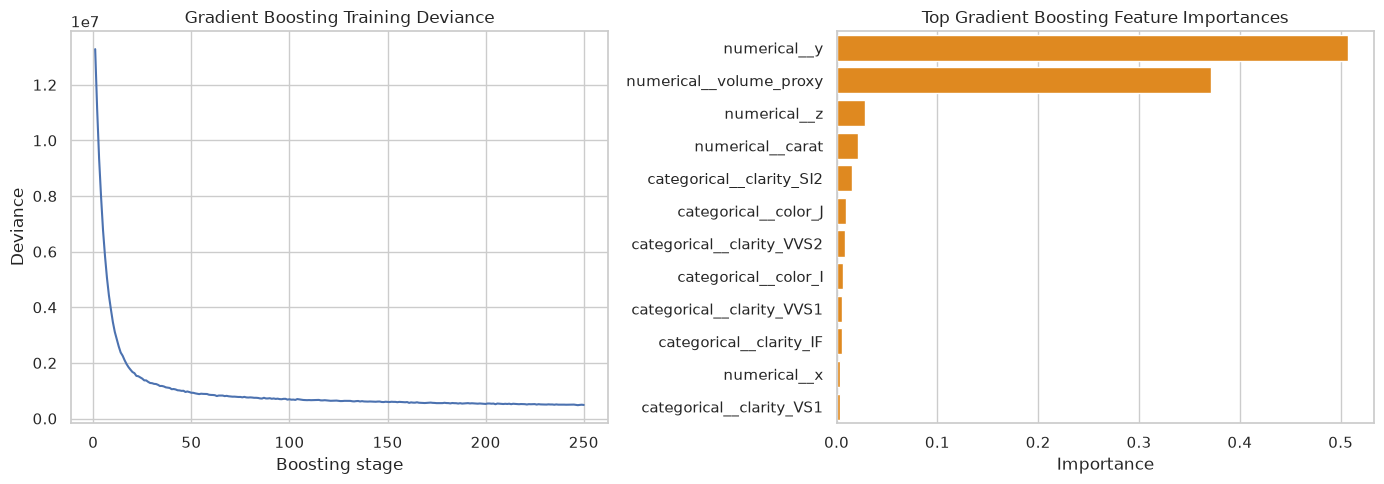

,Feature,Importance
0,numerical__y,0.507644
1,numerical__volume_proxy,0.371553
2,numerical__z,0.027971
3,numerical__carat,0.021641
4,categorical__clarity_SI2,0.015523
5,categorical__color_J,0.009719
6,categorical__clarity_VVS2,0.008342
7,categorical__color_I,0.006043
8,categorical__clarity_VVS1,0.005572
9,categorical__clarity_IF,0.005496


In [52]:
fitted_boosting = gradient_boosting_model.named_steps["regressor"]
boosting_feature_names = gradient_boosting_model.named_steps["preprocessor"].get_feature_names_out()
boosting_importance = pd.DataFrame(
    {
        "Feature": boosting_feature_names,
        "Importance": fitted_boosting.feature_importances_,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    np.arange(1, fitted_boosting.n_estimators_ + 1),
    fitted_boosting.train_score_,
)
axes[0].set(
    title="Gradient Boosting Training Deviance",
    xlabel="Boosting stage",
    ylabel="Deviance",
)
sns.barplot(
    data=boosting_importance.head(12),
    x="Importance",
    y="Feature",
    color="darkorange",
    ax=axes[1],
)
axes[1].set(title="Top Gradient Boosting Feature Importances", ylabel="")
plt.tight_layout()
plt.show()

boosting_importance.head(15)

### Model 8 conclusion

Gradient Boosting is effective for structured data because later trees directly correct earlier residual errors. Compare its test metrics with the bagging-based Random Forest to determine which ensemble strategy generalizes better.

## Model 9: Support Vector Regressor (SVR)

SVR fits a function inside an error-tolerance margin while penalizing predictions outside that margin. A linear kernel learns a straight relationship, while the radial basis function (RBF) kernel can model nonlinear price patterns.

### Confirm scaling and prepare a tuning subset

SVR is highly sensitive to feature scale. The shared preprocessor already standardizes every numerical feature and one-hot encodes categories. The target is also standardized inside `TransformedTargetRegressor` and automatically converted back to dollars for predictions. Parameter tuning uses a reproducible 5,000-row subset because kernel SVR becomes expensive on large datasets.

In [53]:
svr_tuning_size = min(5_000, len(X_train))
svr_tuning_indices = X_train.sample(
    n=svr_tuning_size, random_state=RANDOM_STATE
).index
X_svr_tuning = X_train.loc[svr_tuning_indices]
y_svr_tuning = y_train.loc[svr_tuning_indices]
print(f"SVR tuning rows: {len(X_svr_tuning):,}")

SVR tuning rows: 5,000


### Tune `C` and kernel

Three-fold cross-validation compares linear and RBF kernels at multiple penalty strengths. `C` controls how strongly errors outside the tolerance margin are penalized. The RBF kernel also tests `C=100`; this expensive setting is omitted for the linear kernel to keep tuning practical. The configuration with the lowest cross-validation RMSE is selected.

In [54]:
svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            TransformedTargetRegressor(
                regressor=SVR(cache_size=1000),
                transformer=StandardScaler(),
            ),
        ),
    ]
)

svr_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=[
        {
            "regressor__regressor__C": [1, 10],
            "regressor__regressor__kernel": ["linear"],
        },
        {
            "regressor__regressor__C": [1, 10, 100],
            "regressor__regressor__kernel": ["rbf"],
        },
    ],
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
svr_search.fit(X_svr_tuning, y_svr_tuning)

svr_tuning_results = pd.DataFrame(
    {
        "C": svr_search.cv_results_["param_regressor__regressor__C"],
        "Kernel": svr_search.cv_results_["param_regressor__regressor__kernel"],
        "CV RMSE": -svr_search.cv_results_["mean_test_score"],
    }
).sort_values("CV RMSE", ignore_index=True)

print("Best SVR parameters:", svr_search.best_params_)
display(svr_tuning_results.round(3))

Best SVR parameters: {'regressor__regressor__C': 10, 'regressor__regressor__kernel': 'rbf'}


,C,Kernel,CV RMSE
0,10,rbf,775.609
1,1,rbf,863.194
2,100,rbf,876.282
3,10,linear,1084.148
4,1,linear,1085.740


### Refit the selected SVR on the full training set

In [55]:
svr_model = clone(svr_search.best_estimator_)
svr_model.fit(X_train, y_train)
fitted_svr = svr_model.named_steps["regressor"].regressor_
print(f"Number of support vectors: {len(fitted_svr.support_):,}")

Number of support vectors: 9,402


### Evaluate SVR

In [56]:
svr_train_predictions = svr_model.predict(X_train)
svr_test_predictions = svr_model.predict(X_test)

svr_train_metrics = regression_metrics(y_train, svr_train_predictions)
svr_test_metrics = regression_metrics(y_test, svr_test_predictions)

pd.DataFrame(
    [svr_train_metrics, svr_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,0.984,504.808,299.985
Test set,0.977,606.434,334.974


In [57]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{"Model": "Support Vector Regressor", **svr_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Support Vector Regressor,0.977,606.434,334.974
1,Random Forest Regression,0.973,651.897,297.054
2,Polynomial Regression,0.970,685.682,399.863
3,Gradient Boosting Regressor,0.964,759.233,389.272
4,Decision Tree Regression,0.958,818.197,374.688
5,Ridge Regression,0.929,1061.539,706.293
6,Lasso Regression,0.929,1061.551,706.667
7,Multiple Linear Regression,0.929,1061.555,706.729
8,ElasticNet Regression,0.929,1061.711,705.028


### Plot SVR predictions and residuals

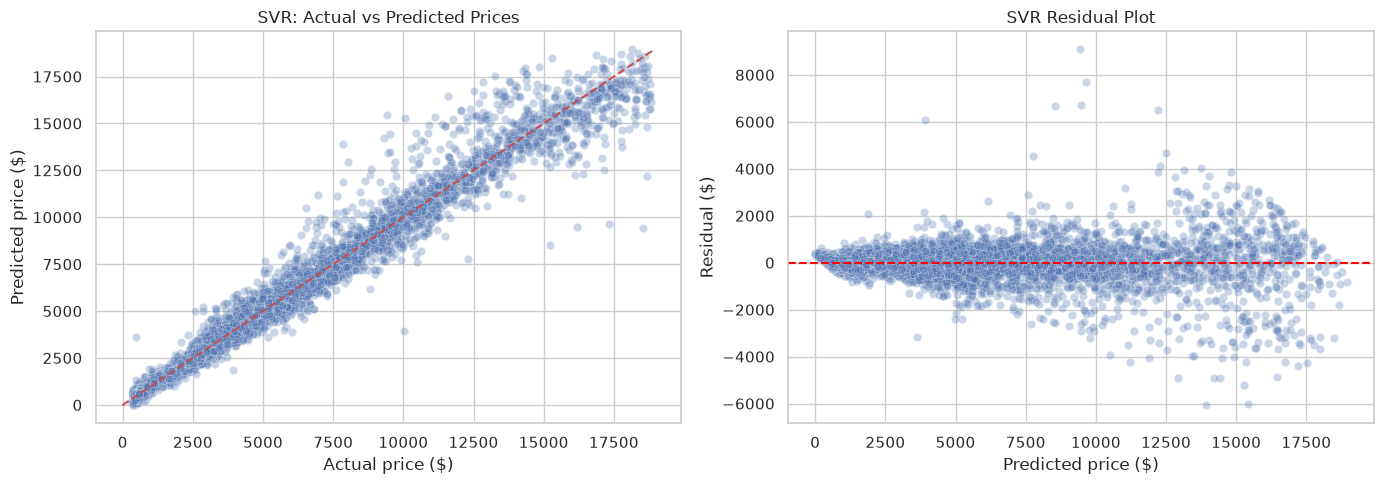

In [58]:
svr_residuals = y_test - svr_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=svr_test_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), svr_test_predictions.min())
plot_max = max(y_test.max(), svr_test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set(
    title="SVR: Actual vs Predicted Prices",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
sns.scatterplot(x=svr_test_predictions, y=svr_residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="SVR Residual Plot",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

## Comparison Through Model 9

The table contains every model currently implemented in this notebook and is ranked by test R². All nine models use the same untouched test set, so their metrics are directly comparable.

,Model,R2 Score,RMSE,MAE
0,Support Vector Regressor,0.977,606.434,334.974
1,Random Forest Regression,0.973,651.897,297.054
2,Polynomial Regression,0.970,685.682,399.863
3,Gradient Boosting Regressor,0.964,759.233,389.272
4,Decision Tree Regression,0.958,818.197,374.688
5,Ridge Regression,0.929,1061.539,706.293
6,Lasso Regression,0.929,1061.551,706.667
7,Multiple Linear Regression,0.929,1061.555,706.729
8,ElasticNet Regression,0.929,1061.711,705.028


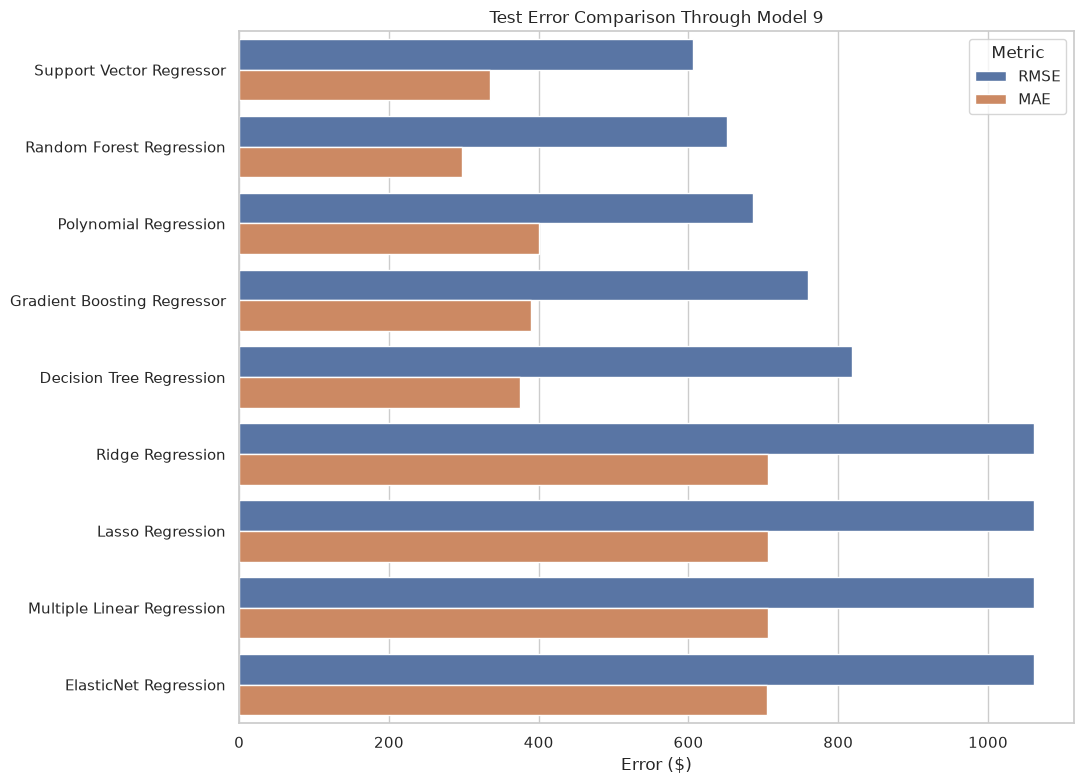

In [59]:
results_df = results_df.sort_values("R2 Score", ascending=False, ignore_index=True)
display(results_df.round(3))

comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Error ($)",
)
plt.figure(figsize=(11, 8))
sns.barplot(data=comparison_long, x="Error ($)", y="Model", hue="Metric")
plt.title("Test Error Comparison Through Model 9")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 9 conclusion

SVR can learn smooth nonlinear price relationships through the RBF kernel, but its training cost grows quickly with the number of rows. Its tuned test metrics show whether the additional computation improves upon the tree ensembles.

## Model 10: K-Nearest Neighbors Regressor

KNN Regression predicts a diamond's price from the prices of its most similar training diamonds. Similarity is measured using distance across the transformed feature space, so both the number of neighbors and feature scaling strongly affect the result.

### Prepare a reproducible tuning subset

Distance calculations become expensive when repeated during cross-validation. A fixed 8,000-row subset of the training data is therefore used to tune `k`; the test set remains completely untouched.

In [60]:
knn_tuning_size = min(8_000, len(X_train))
knn_tuning_indices = X_train.sample(
    n=knn_tuning_size, random_state=RANDOM_STATE
).index
X_knn_tuning = X_train.loc[knn_tuning_indices]
y_knn_tuning = y_train.loc[knn_tuning_indices]
print(f"KNN tuning rows: {len(X_knn_tuning):,}")

KNN tuning rows: 8,000


### Tune the number of neighbors (`k`)

Small `k` values produce flexible predictions but can overfit. Larger values create smoother predictions but may underfit. Three-fold cross-validation selects the `k` with the lowest RMSE. Distance weighting gives closer diamonds more influence than farther neighbors.

In [61]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            KNeighborsRegressor(weights="distance", n_jobs=-1),
        ),
    ]
)

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={"regressor__n_neighbors": [3, 5, 7, 11, 15, 21]},
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
)
knn_search.fit(X_knn_tuning, y_knn_tuning)
best_k = int(knn_search.best_params_["regressor__n_neighbors"])

knn_tuning_results = pd.DataFrame(
    {
        "k": knn_search.cv_results_["param_regressor__n_neighbors"],
        "CV RMSE": -knn_search.cv_results_["mean_test_score"],
    }
).sort_values("k", ignore_index=True)
print(f"Selected k: {best_k}")
display(knn_tuning_results.round(3))

Selected k: 11


,k,CV RMSE
0,3,1133.177
1,5,1075.903
2,7,1054.649
3,11,1053.262
4,15,1065.769
5,21,1071.135


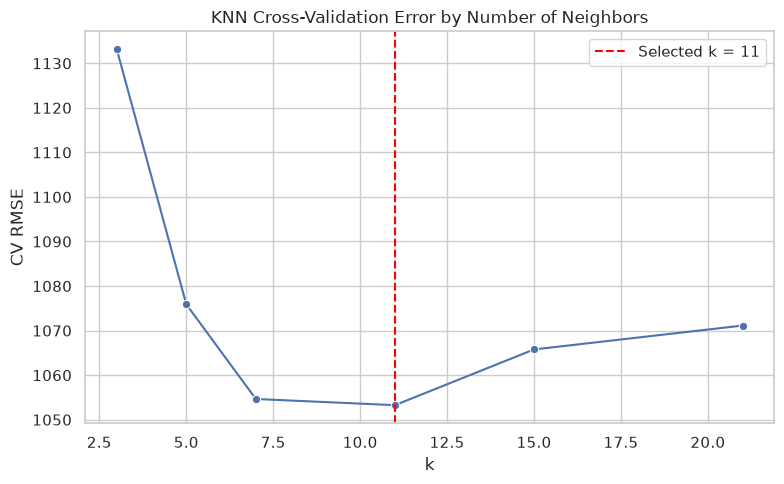

In [62]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=knn_tuning_results, x="k", y="CV RMSE", marker="o"
)
plt.axvline(best_k, color="red", linestyle="--", label=f"Selected k = {best_k}")
plt.title("KNN Cross-Validation Error by Number of Neighbors")
plt.legend()
plt.tight_layout()
plt.show()

### Measure the impact of feature scaling

Without scaling, a feature with a large numeric range can dominate Euclidean distance even when it is not the most informative feature. The experiment below fits scaled and unscaled KNN models on identical rows and compares their validation errors. Categorical features are encoded identically in both cases.

In [63]:
X_knn_scale_train, X_knn_scale_validation, y_knn_scale_train, y_knn_scale_validation = (
    train_test_split(
        X_knn_tuning,
        y_knn_tuning,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )
)

unscaled_numerical_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", unscaled_numerical_pipeline, numerical_features),
        ("categorical", clone(categorical_pipeline), categorical_features),
    ]
)

scaled_knn_comparison = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("regressor", KNeighborsRegressor(n_neighbors=best_k, weights="distance")),
    ]
)
unscaled_knn_comparison = Pipeline(
    steps=[
        ("preprocessor", unscaled_preprocessor),
        ("regressor", KNeighborsRegressor(n_neighbors=best_k, weights="distance")),
    ]
)

scaling_rows = []
for scaling_label, comparison_model in [
    ("Standardized numerical features", scaled_knn_comparison),
    ("Unscaled numerical features", unscaled_knn_comparison),
]:
    comparison_model.fit(X_knn_scale_train, y_knn_scale_train)
    scaling_predictions = comparison_model.predict(X_knn_scale_validation)
    scaling_rows.append(
        {
            "Preprocessing": scaling_label,
            **regression_metrics(y_knn_scale_validation, scaling_predictions),
        }
    )

knn_scaling_results = pd.DataFrame(scaling_rows).sort_values(
    "RMSE", ignore_index=True
)
knn_scaling_results.round(3)

,Preprocessing,R2 Score,RMSE,MAE
0,Standardized numerical features,0.928,1079.907,552.105
1,Unscaled numerical features,0.879,1407.362,731.268


### Train the selected scaled KNN model

The selected `k` is now used with standardized numerical features and the full training set.

In [64]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "regressor",
            KNeighborsRegressor(
                n_neighbors=best_k, weights="distance", n_jobs=-1
            ),
        ),
    ]
)
knn_model.fit(X_train, y_train)
print("KNN training complete.")

KNN training complete.


### Evaluate KNN Regression

In [65]:
knn_train_predictions = knn_model.predict(X_train)
knn_test_predictions = knn_model.predict(X_test)

knn_train_metrics = regression_metrics(y_train, knn_train_predictions)
knn_test_metrics = regression_metrics(y_test, knn_test_predictions)

pd.DataFrame(
    [knn_train_metrics, knn_test_metrics],
    index=["Training set", "Test set"],
).round(3)

,R2 Score,RMSE,MAE
Training set,1.000,20.280,0.634
Test set,0.961,792.178,390.109


In [66]:
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [{"Model": "K-Nearest Neighbors Regressor", **knn_test_metrics}]
        ),
    ],
    ignore_index=True,
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Support Vector Regressor,0.977,606.434,334.974
1,Random Forest Regression,0.973,651.897,297.054
2,Polynomial Regression,0.970,685.682,399.863
3,Gradient Boosting Regressor,0.964,759.233,389.272
4,K-Nearest Neighbors Regressor,0.961,792.178,390.109
5,Decision Tree Regression,0.958,818.197,374.688
6,Ridge Regression,0.929,1061.539,706.293
7,Lasso Regression,0.929,1061.551,706.667
8,Multiple Linear Regression,0.929,1061.555,706.729
9,ElasticNet Regression,0.929,1061.711,705.028


### Plot KNN predictions and residuals

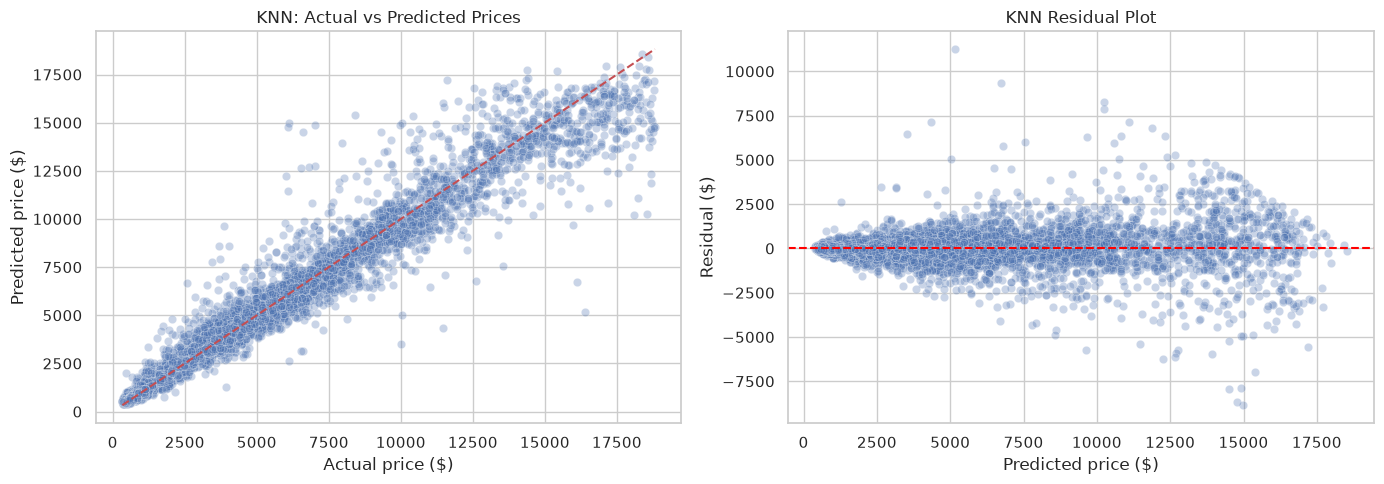

In [67]:
knn_residuals = y_test - knn_test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=knn_test_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), knn_test_predictions.min())
plot_max = max(y_test.max(), knn_test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set(
    title="KNN: Actual vs Predicted Prices",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
sns.scatterplot(x=knn_test_predictions, y=knn_residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="KNN Residual Plot",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

## Final Comparison of All 10 Regression Models

All models use the same training and test split. The final table is ranked by test R²; the best model should combine high R² with low RMSE and MAE.

In [68]:
final_results = results_df.sort_values(
    "R2 Score", ascending=False, ignore_index=True
)
display(final_results.round(3))

best_model = final_results.iloc[0]
print(f"Best model by test R²: {best_model['Model']}")
print(f"R²: {best_model['R2 Score']:.4f}")
print(f"RMSE: ${best_model['RMSE']:,.3f}")
print(f"MAE: ${best_model['MAE']:,.3f}")

,Model,R2 Score,RMSE,MAE
0,Support Vector Regressor,0.977,606.434,334.974
1,Random Forest Regression,0.973,651.897,297.054
2,Polynomial Regression,0.970,685.682,399.863
3,Gradient Boosting Regressor,0.964,759.233,389.272
4,K-Nearest Neighbors Regressor,0.961,792.178,390.109
5,Decision Tree Regression,0.958,818.197,374.688
6,Ridge Regression,0.929,1061.539,706.293
7,Lasso Regression,0.929,1061.551,706.667
8,Multiple Linear Regression,0.929,1061.555,706.729
9,ElasticNet Regression,0.929,1061.711,705.028


Best model by test R²: Support Vector Regressor
R²: 0.9769
RMSE: $606.434
MAE: $334.974


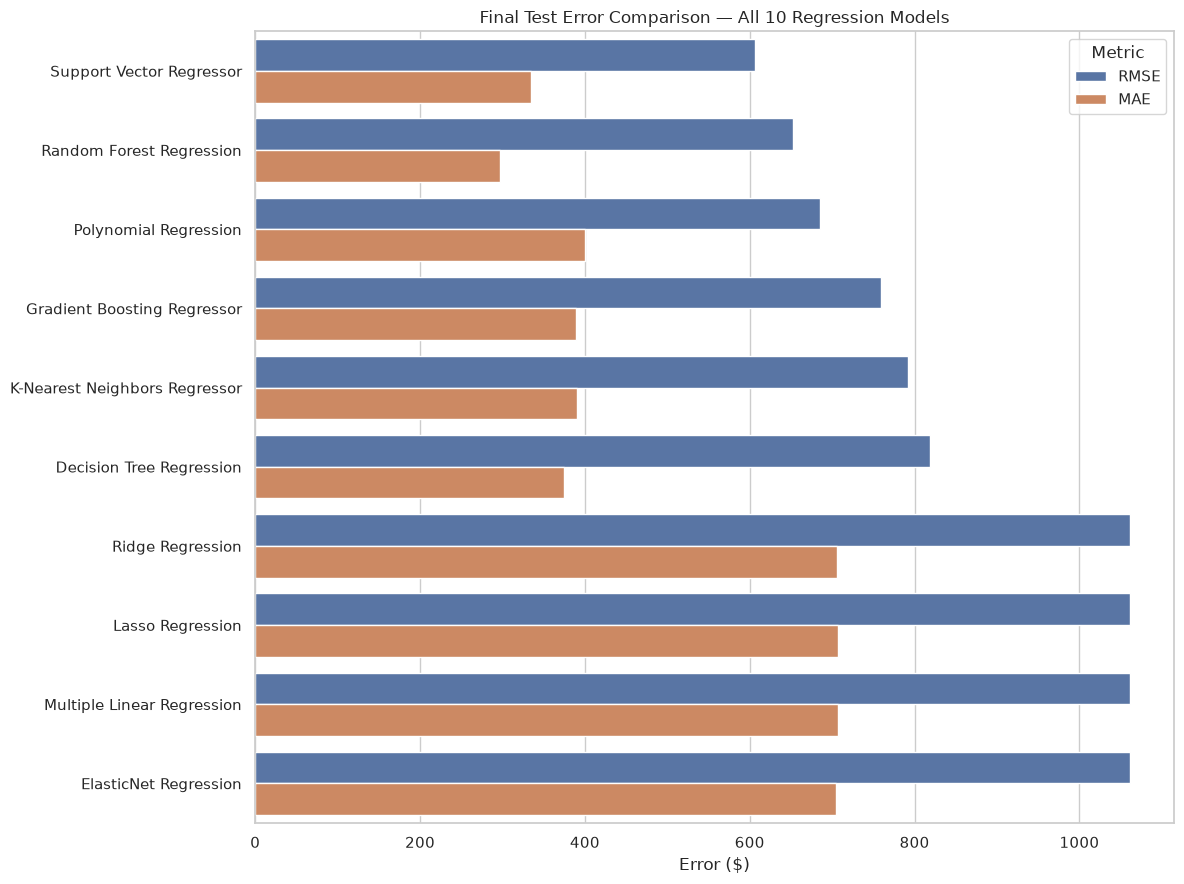

In [69]:
final_comparison_long = final_results.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Error ($)",
)
plt.figure(figsize=(12, 9))
sns.barplot(
    data=final_comparison_long,
    x="Error ($)",
    y="Model",
    hue="Metric",
)
plt.title("Final Test Error Comparison — All 10 Regression Models")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Model 10 conclusion

KNN can model nonlinear local patterns without assuming a global equation. Its scaling experiment demonstrates why distance-based algorithms require comparable feature scales. The final ranking determines how this local method compares with linear, regularized, polynomial, tree, ensemble, and kernel-based regressors.

## Tuning evidence

The rubric asks for hyperparameter tuning on at least two models and for the improvement to be visible. The table below compares the default configuration included in each search with the selected configuration using the same cross-validation folds. A positive RMSE reduction means tuning helped.

In [70]:
ridge_default_index = next(
    index
    for index, params in enumerate(ridge_search.cv_results_["params"])
    if float(params["regressor__alpha"]) == 1.0
)
tree_default_index = next(
    index
    for index, params in enumerate(decision_tree_search.cv_results_["params"])
    if params["regressor__max_depth"] is None
    and params["regressor__min_samples_leaf"] == 1
)

tuning_summary = pd.DataFrame(
    [
        {
            "Model": "Ridge Regression",
            "Default parameters": "alpha=1.0",
            "Best parameters": str(ridge_search.best_params_),
            "Default CV RMSE": -ridge_search.cv_results_["mean_test_score"][ridge_default_index],
            "Tuned CV RMSE": -ridge_search.best_score_,
        },
        {
            "Model": "Decision Tree Regression",
            "Default parameters": "max_depth=None, min_samples_leaf=1",
            "Best parameters": str(decision_tree_search.best_params_),
            "Default CV RMSE": -decision_tree_search.cv_results_["mean_test_score"][tree_default_index],
            "Tuned CV RMSE": -decision_tree_search.best_score_,
        },
    ]
)
tuning_summary["RMSE reduction"] = (
    tuning_summary["Default CV RMSE"] - tuning_summary["Tuned CV RMSE"]
)
tuning_summary.round(3)

,Model,Default parameters,Best parameters,Default CV RMSE,Tuned CV RMSE,RMSE reduction
0,Ridge Regression,alpha=1.0,{'regressor__alpha': np.float64(1.0)},1054.867,1054.867,0.000
1,Decision Tree Regression,"max_depth=None, min_samples_leaf=1","{'regressor__max_depth': 16, 'regressor__min_s...",895.720,821.747,73.973


## Five-fold validation of the two leading models

The final test set remains the common, untouched comparison set. As an additional stability check required by the guidelines, I run shuffled five-fold cross-validation on the training portion for the two models ranked highest by test R². The mean and standard deviation show whether their performance is consistent across different folds.

In [71]:
model_registry = {
    "Multiple Linear Regression": linear_regression_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression": elastic_net_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regression": decision_tree_model,
    "Random Forest Regression": random_forest_model,
    "Gradient Boosting Regressor": gradient_boosting_model,
    "Support Vector Regressor": svr_model,
    "K-Nearest Neighbors Regressor": knn_model,
}

top_two_names = final_results.head(2)["Model"].tolist()
five_fold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for model_name in top_two_names:
    fold_scores = cross_val_score(
        clone(model_registry[model_name]),
        X_train,
        y_train,
        cv=five_fold,
        scoring="r2",
        n_jobs=-1,
    )
    cv_rows.append(
        {
            "Model": model_name,
            "Fold R2 scores": np.round(fold_scores, 4),
            "Mean 5-fold R2": fold_scores.mean(),
            "Std. 5-fold R2": fold_scores.std(),
        }
    )

cross_validation_results = pd.DataFrame(cv_rows)
cross_validation_results

,Model,Fold R2 scores,Mean 5-fold R2,Std. 5-fold R2
0,Support Vector Regressor,"[0.9783, 0.9796, 0.9791, 0.9784, 0.9779]",0.978647,0.000610
1,Random Forest Regression,"[0.9722, 0.9754, 0.9752, 0.9736, 0.9709]",0.973461,0.001732


## Final model diagnostics

These plots are generated from whichever model actually ranks first, rather than assuming in advance that a particular algorithm will win. Points close to the diagonal are accurate predictions. In the residual plot, a centred, pattern-free cloud is desirable; widening spread at high predicted prices would mean the expensive diamonds remain harder to estimate.

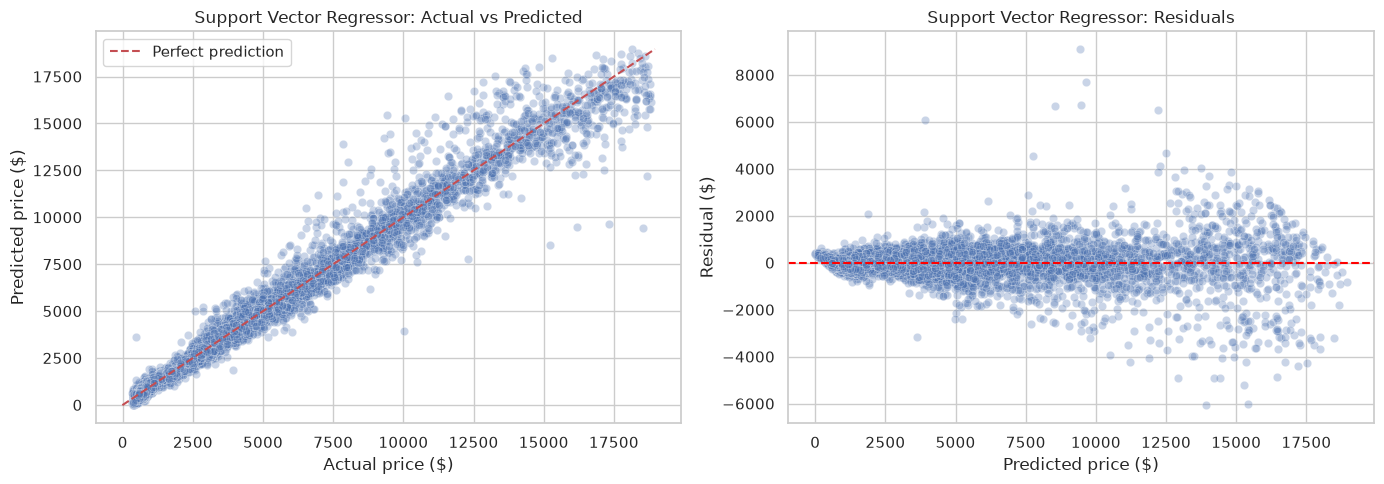

Selected model: Support Vector Regressor
Mean residual: $-3.80
Median absolute residual: $195.17


In [72]:
best_model_name = final_results.loc[0, "Model"]
best_fitted_model = model_registry[best_model_name]
best_predictions = best_fitted_model.predict(X_test)
best_residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.3, ax=axes[0])
plot_min = min(y_test.min(), best_predictions.min())
plot_max = max(y_test.max(), best_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--", label="Perfect prediction")
axes[0].set(
    title=f"{best_model_name}: Actual vs Predicted",
    xlabel="Actual price ($)",
    ylabel="Predicted price ($)",
)
axes[0].legend()
sns.scatterplot(x=best_predictions, y=best_residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title=f"{best_model_name}: Residuals",
    xlabel="Predicted price ($)",
    ylabel="Residual ($)",
)
plt.tight_layout()
plt.show()

print(f"Selected model: {best_model_name}")
print(f"Mean residual: ${best_residuals.mean():,.2f}")
print(f"Median absolute residual: ${np.median(np.abs(best_residuals)):,.2f}")

## Conclusion

SVR is the strongest overall model here: it reaches a test R² of 0.9769, with an RMSE of $606.43 and an MAE of $334.97. Its five-fold R² of 0.9786 ± 0.0006 is reassuringly stable, and the mean residual of -$3.80 shows almost no overall directional bias. Random Forest is still worth mentioning in the review: it ranks second by R² but has the lowest MAE ($297.05), so it makes smaller errors on a typical prediction even though its larger misses raise RMSE.

The model comparison also matches what the EDA suggested. Linear models stop near R² = 0.929 because one straight relationship cannot capture the curved price–size pattern, while the nonlinear models improve substantially. This study supports prediction, not causation, and it remains tied to the range and grading conventions of the assigned dataset. Before using it on diamonds from another source, I would check for distribution shift and revalidate it on recent labelled examples.